In [417]:
from pathlib import Path
import numpy as np
import tifffile
import matplotlib.pyplot as plt

files = {
    "cirbg":    Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30/7.30 right bg s1/7.30 right bg s1_MMStack_Pos0.ome.tif"),   
    "cirsamp":    Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30/7.30 left sample0 s1/7.30 left sample0 s1_MMStack_Pos0.ome.tif"),   
}

for key, path in files.items():
    print(f"{key}: exists={path.exists()} -> {path}")

cirbg: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.30/7.30 right bg s1/7.30 right bg s1_MMStack_Pos0.ome.tif
cirsamp: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.30/7.30 left sample0 s1/7.30 left sample0 s1_MMStack_Pos0.ome.tif


In [418]:
def load_ome_tif(path):
    """
    Read OME-TIFF and return one 2D float64 image.
    If multiple frames exist, use the first frame after squeeze.
    """
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    arr = tifffile.imread(path)
    arr = np.squeeze(arr)

    print(f"{path.name}: shape={arr.shape}, dtype={arr.dtype}")

    if arr.ndim == 2:
        img = arr
    elif arr.ndim == 3:
        print(f"Warning: using first frame arr[0] from shape {arr.shape}")
        img = arr[0]
    else:
        raise ValueError(f"Unsupported image shape: {arr.shape}")

    return img.astype(np.float64)

7.30 left sample0 s1_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
Loaded image shape: (2048, 2432)
min/max: 11.0 501.0


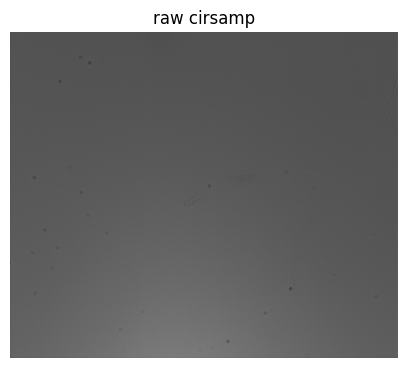

In [419]:
raw_test = load_ome_tif(files["cirsamp"])

print("Loaded image shape:", raw_test.shape)
print("min/max:", raw_test.min(), raw_test.max())

plt.figure(figsize=(5, 5))
plt.imshow(raw_test, cmap="gray")
plt.title("raw cirsamp")
plt.axis("off")
plt.show()

7.30 right bg s1_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
Loaded image shape: (2048, 2432)
min/max: 112.0 298.0


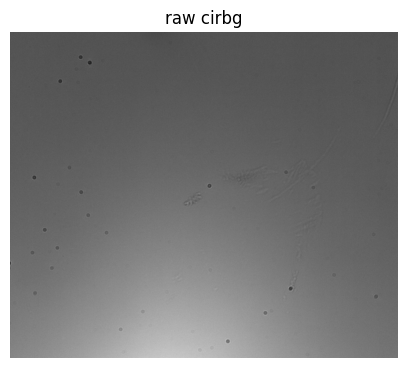

In [420]:
raw_test = load_ome_tif(files["cirbg"])

print("Loaded image shape:", raw_test.shape)
print("min/max:", raw_test.min(), raw_test.max())

plt.figure(figsize=(5, 5))
plt.imshow(raw_test, cmap="gray")
plt.title("raw cirbg")
plt.axis("off")
plt.show()

In [421]:
def split_pol_channels(raw):
    """
    Split raw mosaic using pattern:
        [ I0,  I135  ]
        [ I45,   I90 ]
    """
    if raw.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {raw.shape}")

    I0  = raw[0::2, 0::2]
    I135  = raw[0::2, 1::2]
    I45   = raw[1::2, 0::2]
    I90 = raw[1::2, 1::2]

    return I0, I45, I90, I135

7.30 left sample0 s1_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
Inspecting: cirsamp
I0 shape   : (1024, 1216)
I45 shape  : (1024, 1216)
I90 shape  : (1024, 1216)
I135 shape : (1024, 1216)


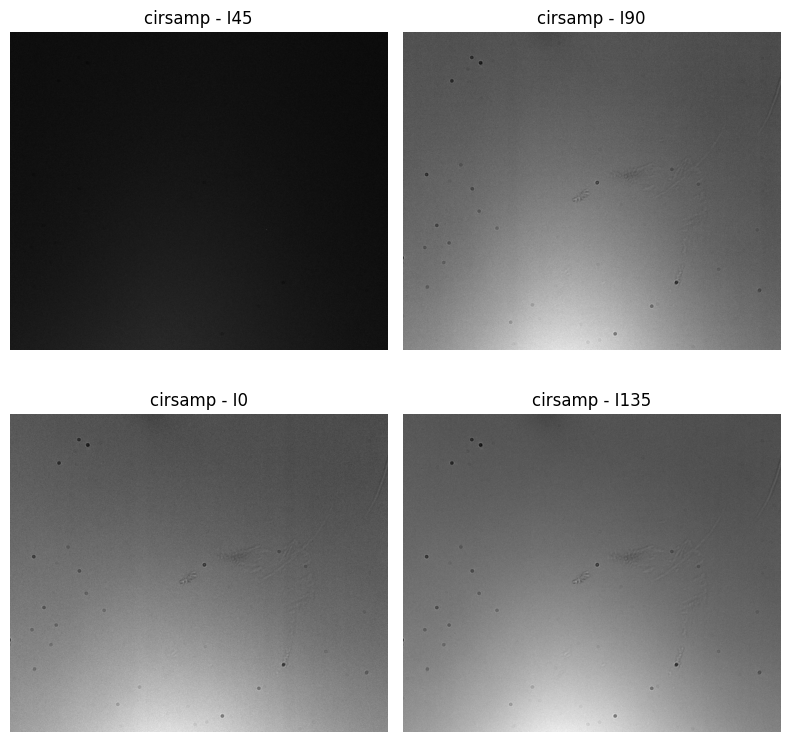

In [422]:
inspect_key = "cirsamp"
raw_inspect = load_ome_tif(files[inspect_key])

I0, I45, I90, I135 = split_pol_channels(raw_inspect)

print(f"Inspecting: {inspect_key}")
print("I0 shape   :", I0.shape)
print("I45 shape  :", I45.shape)
print("I90 shape  :", I90.shape)
print("I135 shape :", I135.shape)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0, 0].imshow(I45, cmap="gray")
axes[0, 0].set_title("cirsamp - I45")

axes[0, 1].imshow(I90, cmap="gray")
axes[0, 1].set_title("cirsamp - I90")

axes[1, 0].imshow(I0, cmap="gray")
axes[1, 0].set_title("cirsamp - I0")

axes[1, 1].imshow(I135, cmap="gray")
axes[1, 1].set_title("cirsamp - I135")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

In [423]:
def stokes_from_raw(raw, eps=1e-12):
    """
    Compute Stokes maps from one raw image.
    Main quantities used later are normalized s1 and s2.
    """
    I0, I45, I90, I135 = split_pol_channels(raw)

    S0 = 0.5 * (I0 + I45 + I90 + I135)
    S1 = I0 - I90
    S2 = I45 - I135

    s1 = S1 / (S0 + eps)
    s2 = S2 / (S0 + eps)

    return {
        "I0": I0,
        "I45": I45,
        "I90": I90,
        "I135": I135,
        "S0": S0,
        "S1": S1,
        "S2": S2,
        "s1": s1,
        "s2": s2,
    }

In [424]:
def compute_theta_delta(I0, I45, I90, I135, eps=1e-8):
    """
    Compute orientation (theta) and phase retardance (delta) from
    four polarization-resolved intensity images.

    Formula used:
        theta = 0.5 * atan2(I90 - I0, I135 - I45)
        delta = arcsin(
                    2 * sqrt((I90 - I0)^2 + (I135 - I45)^2) /
                    (I0 + I45 + I90 + I135)
                )

    Returns
    -------
    theta_deg : ndarray
        Orientation in degrees, mapped to [0, 180).
    delta_deg : ndarray
        Phase retardance in degrees, clipped to [0, 180].
    """
    # 转 float，避免整型溢出
    I0   = I0.astype(np.float32)
    I45  = I45.astype(np.float32)
    I90  = I90.astype(np.float32)
    I135 = I135.astype(np.float32)

    # numerator components
    a = I90 - I0
    b = I135 - I45

    # -------- theta --------
    theta_rad = 0.5 * np.arctan2(-a,b)
    theta_deg = np.degrees(theta_rad)

    # 映射到 [0, 180)
    theta_deg = np.mod(theta_deg,180)

    # -------- delta --------
    denom = I0 + I45 + I90 + I135
    numer = 2.0 * np.sqrt(a**2 + b**2)

    ratio = numer / (denom + eps)

    # arcsin 输入必须在 [-1, 1]
    ratio = np.clip(ratio, -1.0, 1.0)

    delta_rad = np.arcsin(ratio)
    delta_deg = np.degrees(delta_rad)

    # 限制到 [0, 180]
    delta_deg = np.clip(delta_deg, 0.0, 90.0)

    return theta_deg, delta_deg

In [425]:
inspect_key = "cirsamp"
raw_inspect = load_ome_tif(files[inspect_key])

I0, I45, I90, I135 = split_pol_channels(raw_inspect)

theta, delta = compute_theta_delta(I0, I45, I90, I135)

print(f"Inspecting: {inspect_key}")
print("I0 shape    :", I0.shape)
print("I45 shape   :", I45.shape)
print("I90 shape   :", I90.shape)
print("I135 shape  :", I135.shape)
print("theta shape :", theta.shape)
print("delta shape :", delta.shape)
print("theta range :", np.nanmin(theta), "to", np.nanmax(theta))
print("delta range :", np.nanmin(delta), "to", np.nanmax(delta))

7.30 left sample0 s1_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
Inspecting: cirsamp
I0 shape    : (1024, 1216)
I45 shape   : (1024, 1216)
I90 shape   : (1024, 1216)
I135 shape  : (1024, 1216)
theta shape : (1024, 1216)
delta shape : (1024, 1216)
theta range : 173.65762 to 179.53168
delta range : 41.52762 to 83.115295


In [426]:
# 将 save_dir 声明/转换为 Path 对象
save_dir = Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 _single shot_QWP different orientations/7.30 0 QWP_single shot")

# 如果文件夹不存在，自动创建（避免因缺少目录导致写入报错）
save_dir.mkdir(parents=True, exist_ok=True)


theta_save_path = save_dir / f"{inspect_key}_theta.tiff"
delta_save_path = save_dir /f"{inspect_key}_delta.tiff"


tifffile.imwrite(theta_save_path, theta.astype(np.float32))
tifffile.imwrite(delta_save_path, delta.astype(np.float32))

print(f"Saved: {inspect_key}_theta.tiff")
print(f"Saved: {inspect_key}_delta.tiff")

Saved: cirsamp_theta.tiff
Saved: cirsamp_delta.tiff
